# 📊 ASSIGNMENT 4 — Thống kê cho AI
## EDA + Kiểm định giả thuyết · Dataset Titanic (891 hành khách)

> **Triết lý:** Trực giác trước, công thức sau. Thư viện lo tính, mình lo *hiểu*.
>
> Quy trình: thống kê mô tả → trực quan → tương quan → **kiểm định giả thuyết** → insight.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
df = pd.read_csv("titanic.csv")
print("Shape:", df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Câu 1 — Mean, median, std. Biến nào lệch mạnh?

In [2]:
num_cols = ["age", "fare", "sibsp", "parch"]
desc = df[num_cols].agg(["mean", "median", "std", "skew"]).T
desc.columns = ["mean", "median", "std", "skew (độ lệch)"]
desc.round(2)

,mean,median,std,skew (độ lệch)
age,29.70,28.00,14.53,0.39
fare,32.20,14.45,49.69,4.79
sibsp,0.52,0.00,1.10,3.70
parch,0.38,0.00,0.81,2.75


**Nhận định:** `fare` **lệch phải rất mạnh** (skew ≈ 4.79 ≫ 1).
Dấu hiệu nhận biết: **mean (32.2) ≫ median (14.5)** — vài vé hạng nhất cực đắt kéo trung bình lên,
trong khi nửa số khách trả ≤ 14.5. `age` gần đối xứng (skew ≈ 0.39).
> 📌 Quy tắc: mean ≫ median → lệch phải; mean ≪ median → lệch trái; |skew| > 1 là lệch đáng kể.

## Câu 2 — Boxplot & outlier

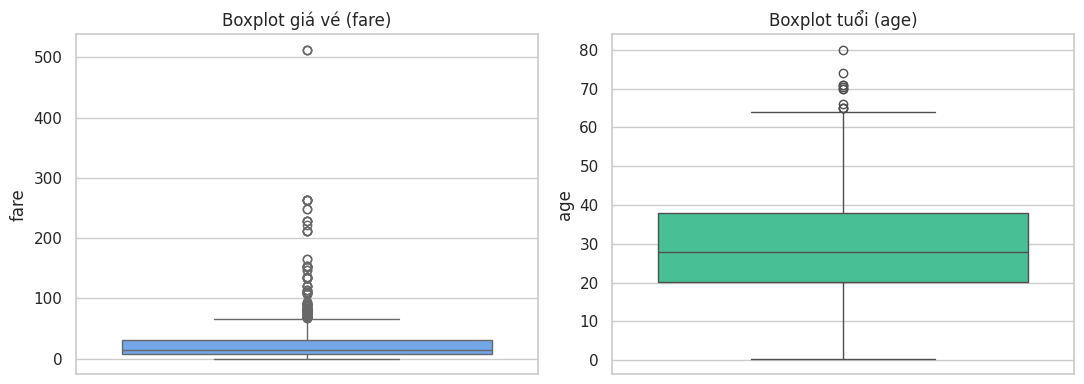

Ngưỡng outlier fare (Q3 + 1.5*IQR): 65.6
Số outlier fare: 116 (13.0%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df["fare"], ax=axes[0], color="#60a5fa")
axes[0].set_title("Boxplot giá vé (fare)")
sns.boxplot(y=df["age"], ax=axes[1], color="#34d399")
axes[1].set_title("Boxplot tuổi (age)")
plt.tight_layout(); plt.show()

# Đếm outlier theo quy tắc IQR
q1, q3 = df["fare"].quantile([.25, .75]); iqr = q3 - q1
upper = q3 + 1.5 * iqr
n_out = (df["fare"] > upper).sum()
print(f"Ngưỡng outlier fare (Q3 + 1.5*IQR): {upper:.1f}")
print(f"Số outlier fare: {n_out} ({n_out/len(df):.1%})")

**Nhận định:** `fare` có nhiều outlier phía trên (giá vé > ~65), khớp với độ lệch phải ở câu 1.
Đây là **outlier thật** (vé hạng nhất sang trọng), KHÔNG phải lỗi nhập liệu → không nên xoá vô tội vạ.

## Câu 3 — Histogram biến mục tiêu (survived)

/tmp/ipykernel_546/2343959297.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Không sống (0)", "Sống (1)"])


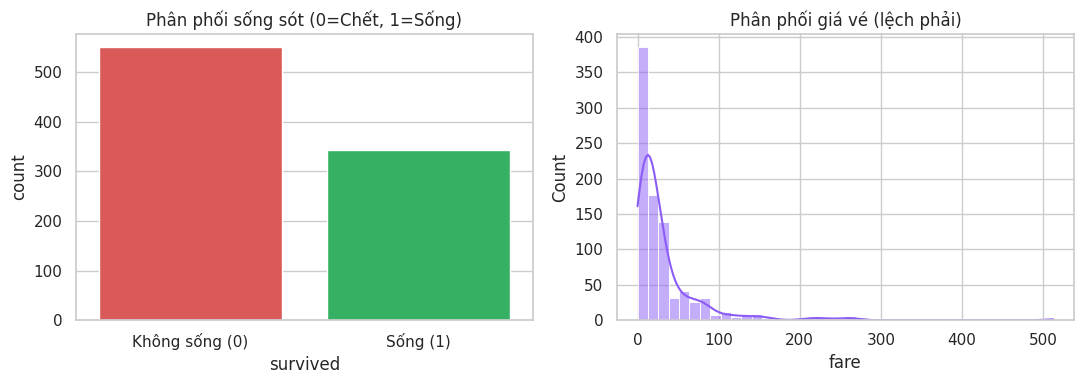

Tỉ lệ sống sót tổng thể: 38.4%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="survived", data=df, ax=axes[0], hue="survived",
              palette=["#ef4444", "#22c55e"], legend=False)
axes[0].set_title("Phân phối sống sót (0=Chết, 1=Sống)")
axes[0].set_xticklabels(["Không sống (0)", "Sống (1)"])

sns.histplot(df["fare"], bins=40, kde=True, ax=axes[1], color="#8b5cf6")
axes[1].set_title("Phân phối giá vé (lệch phải)")
plt.tight_layout(); plt.show()

print("Tỉ lệ sống sót tổng thể:", f"{df.survived.mean():.1%}")

**Nhận định:** Dữ liệu **mất cân bằng** — chỉ ~38.4% sống sót.
Histogram `fare` xác nhận đuôi phải dài (right-skewed) như câu 1–2.

## Câu 4 — Ma trận tương quan & heatmap

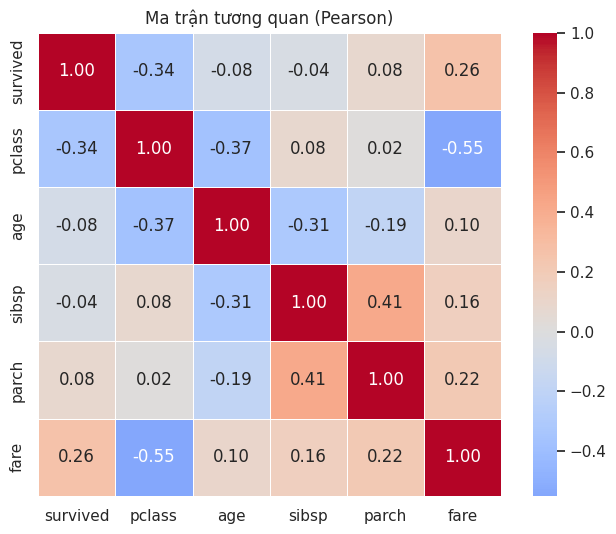

In [5]:
corr = df[["survived", "pclass", "age", "sibsp", "parch", "fare"]].corr()
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5)
plt.title("Ma trận tương quan (Pearson)")
plt.tight_layout(); plt.show()

**Nhận định:** Cặp tương quan mạnh nhất là **`pclass` ↔ `fare` (≈ −0.55)**:
hạng vé số nhỏ (hạng 1) → giá vé cao (quan hệ nghịch, vì hạng 1 < 2 < 3 về số).
Với biến mục tiêu: `fare` tương quan dương với `survived` (≈ +0.26), `pclass` âm (≈ −0.34)
→ khách giàu/hạng cao sống sót nhiều hơn. *Lưu ý: tương quan ≠ nhân quả.*

## Câu 5 — % giá trị thiếu & cách xử lý

In [6]:
miss = (df.isnull().mean() * 100).round(1)
print("% thiếu mỗi cột (chỉ cột > 0):")
print(miss[miss > 0].sort_values(ascending=False))

% thiếu mỗi cột (chỉ cột > 0):
deck           77.2
age            19.9
embarked        0.2
embark_town     0.2
dtype: float64


**Cách xử lý — tuỳ tỷ lệ thiếu & bản chất cột:**

| Cột | % thiếu | Cách | Lý do |
|-----|--------:|------|-------|
| `deck` | 77.2% | **bỏ cột** | Thiếu quá nhiều, điền vào là bịa dữ liệu |
| `age` | 19.9% | **điền median** | Số liên tục, median bền với outlier; giữ được 20% dữ liệu |
| `embarked` | 0.2% | **điền mode** | Biến phân loại → điền giá trị phổ biến nhất |

> 📌 Không có công thức chung: ID/text → khác; số liên tục → median; phân loại → mode;
> thiếu > ~50% → cân nhắc bỏ cột.

In [7]:
df_clean = df.copy()
df_clean = df_clean.drop(columns=["deck"])
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())
df_clean["embarked"] = df_clean["embarked"].fillna(df_clean["embarked"].mode()[0])
print("Missing còn lại (cột chính):", df_clean[["age","embarked"]].isnull().sum().sum())

Missing còn lại (cột chính): 0


## Câu 6 — Phát biểu giả thuyết

**Câu hỏi nghiệp vụ:** Giới tính có ảnh hưởng đến tỉ lệ sống sót không?

- **H₀ (giả thuyết gốc):** Giới tính và việc sống sót **độc lập** — tỉ lệ sống sót như nhau giữa nam và nữ.
- **H₁ (giả thuyết đối):** Giới tính và sống sót **có liên hệ** — tỉ lệ sống sót khác nhau.
- **Mức ý nghĩa:** α = **0.05**.

## Câu 7 — Chọn kiểm định & lý do

➡️ Dùng **Chi-square test of independence (χ²)**.

**Vì sao chi-square, không phải t-test?**
- Cả `sex` (nam/nữ) và `survived` (sống/chết) đều là **biến phân loại (categorical)**.
- t-test so sánh **trung bình của biến số** giữa 2 nhóm → không hợp ở đây.
- Chi-square kiểm tra mối **liên hệ giữa hai biến phân loại** qua bảng tần suất → đúng bài toán.

## Câu 8 — Chạy kiểm định, p-value & kết luận

In [8]:
# Bảng tần suất (contingency table)
ct = pd.crosstab(df["sex"], df["survived"])
print("Bảng tần suất sex × survived:")
print(ct)

chi2, p_value, dof, expected = stats.chi2_contingency(ct)
print(f"\nChi-square = {chi2:.2f}")
print(f"Bậc tự do (dof) = {dof}")
print(f"p-value = {p_value:.2e}")

alpha = 0.05
print(f"\nTỉ lệ sống — Nữ: {df[df.sex=='female'].survived.mean():.1%} | "
      f"Nam: {df[df.sex=='male'].survived.mean():.1%}")
print("=> " + ("BÁC BỎ H₀" if p_value < alpha else "KHÔNG bác bỏ H₀"))

Bảng tần suất sex × survived:
survived    0    1
sex               
female     81  233
male      468  109

Chi-square = 260.72
Bậc tự do (dof) = 1
p-value = 1.20e-58

Tỉ lệ sống — Nữ: 74.2% | Nam: 18.9%
=> BÁC BỎ H₀


**Kết luận:** p-value ≈ 1.2 × 10⁻⁵⁸ ≪ α = 0.05 → **bác bỏ H₀**.
Có bằng chứng thống kê rất mạnh rằng **giới tính ảnh hưởng tỉ lệ sống sót**
(nữ 74.2% vs nam 18.9% — "phụ nữ và trẻ em trước").

> ⚠️ **Đọc p-value đúng cách:** p KHÔNG phải "xác suất H₀ đúng". Nó là *xác suất quan sát được dữ liệu
> chênh lệch như vậy (hoặc hơn) NẾU H₀ đúng*. p nhỏ → dữ liệu khó xảy ra dưới H₀ → nghi ngờ H₀.

### 🔁 Bonus — t-test cho biến SỐ (giá vé)
Để minh hoạ khi nào dùng t-test: so sánh **giá vé trung bình** giữa nhóm sống và chết.
H₀: giá vé TB hai nhóm bằng nhau. (fare là biến số → t-test là đúng.)

In [9]:
fare_song = df[df.survived == 1]["fare"]
fare_chet = df[df.survived == 0]["fare"]

# Welch's t-test (không giả định phương sai bằng nhau - an toàn hơn)
t_stat, p_t = stats.ttest_ind(fare_song, fare_chet, equal_var=False)
print(f"Giá vé TB — Sống: {fare_song.mean():.1f} | Chết: {fare_chet.mean():.1f}")
print(f"t = {t_stat:.2f}, p-value = {p_t:.2e}")
print("=> " + ("BÁC BỎ H₀" if p_t < 0.05 else "KHÔNG bác bỏ H₀") +
      ": giá vé khác biệt có ý nghĩa giữa 2 nhóm")

Giá vé TB — Sống: 48.4 | Chết: 22.1
t = 6.84, p-value = 2.70e-11
=> BÁC BỎ H₀: giá vé khác biệt có ý nghĩa giữa 2 nhóm


## Câu 9 — Khoảng tin cậy 95% cho giá vé trung bình

In [10]:
data = df["fare"].dropna()
n = len(data)
mean = data.mean()
sem = stats.sem(data)                       # sai số chuẩn của trung bình
ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)

print(f"Giá vé trung bình mẫu: {mean:.2f}")
print(f"Khoảng tin cậy 95%: [{ci_low:.2f}, {ci_high:.2f}]")

Giá vé trung bình mẫu: 32.20
Khoảng tin cậy 95%: [28.94, 35.47]


**Nhận định:** Ta tin 95% rằng giá vé trung bình *thật* của tổng thể nằm trong khoảng ~[28.9, 35.5].

> ⚠️ **Hiểu đúng 95% CI:** KHÔNG phải "95% hành khách có giá vé trong khoảng này".
> Nó nói về độ chính xác của **ước lượng trung bình**: nếu lặp lại lấy mẫu nhiều lần,
> ~95% các khoảng tính được sẽ chứa giá trị trung bình thật.

## Câu 10 — Tổng hợp 3 insight thống kê quan trọng nhất

**1. Giới tính là yếu tố sống còn mạnh nhất (χ², p ≈ 10⁻⁵⁸).**
Nữ sống sót 74.2%, nam chỉ 18.9% — chênh lệch gần 4 lần, có ý nghĩa thống kê cực mạnh.
Đây không phải ngẫu nhiên mà phản ánh chính sách "phụ nữ & trẻ em trước".

**2. Tầng lớp kinh tế quyết định cơ hội sống (fare/pclass).**
`fare` tương quan dương với sống sót (+0.26), `pclass` âm (−0.34), và t-test giá vé
p ≈ 10⁻¹¹ → khách hạng cao/giàu sống sót nhiều hơn rõ rệt. Khoang hạng 1 gần boong & xuồng cứu sinh.

**3. Dữ liệu lệch & thiếu là chuyện bình thường — phải xử lý có tư duy.**
`fare` lệch phải mạnh (dùng median, không mean để mô tả "điển hình"); `deck` thiếu 77% (bỏ),
`age` thiếu 20% (điền median). Bỏ qua những điều này → thống kê sai lệch.

> ✅ **Bài học cốt lõi:** biến quan sát thành kết luận **có cơ sở** — nêu rõ H₀/H₁, chọn đúng kiểm định
> (chi-square cho phân loại, t-test cho biến số), đọc p-value & CI đúng nghĩa. Đó là khác biệt giữa
> "cảm thấy" và "chứng minh được".